1. IMPORT LIBRARY

In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')


2. LOAD MODEL AND PREDICTION RESULT FROM MODELLING SECTION

In [5]:
model = joblib.load('model_rumah.pkl')
feature_columns = joblib.load('feature_columns.pkl')

y_test = pd.read_csv('y_test.csv')['price']
y_pred = pd.read_csv('y_pred_best.csv')['y_pred']
X_test = pd.read_csv('X_test.csv')

3. SUMMARY OF EVALUATION METRICS

In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 : {r2:.4f}")
print(f"MAPE : {mape:.2f}")


MAE : 95,342.13
RMSE : 308.78
R2 : 0.5911
MAPE : inf


4. ACTUAL AND PREDICTED PRICE CHART

Text(0.5, 1.0, 'Actual Price Vs Predicted Price')

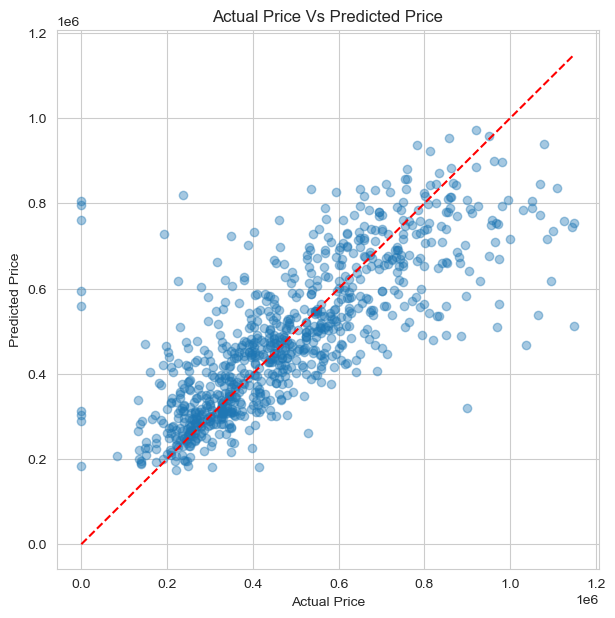

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price Vs Predicted Price')

5. RESIDUAL DISTRIBUTION

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


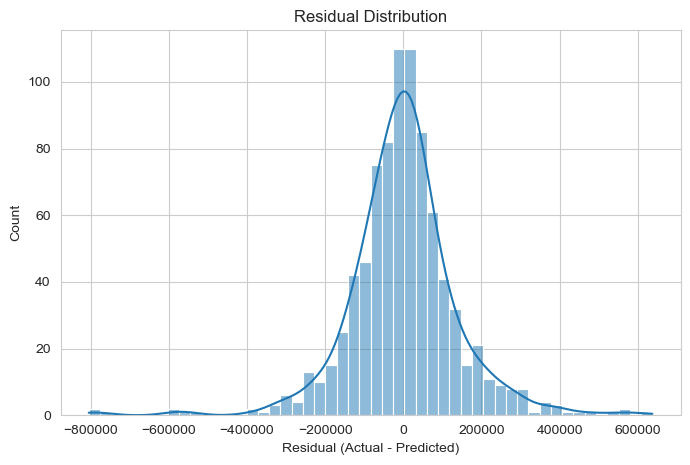

In [8]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

6. RESIDUAL TO PREDICTED PRICE

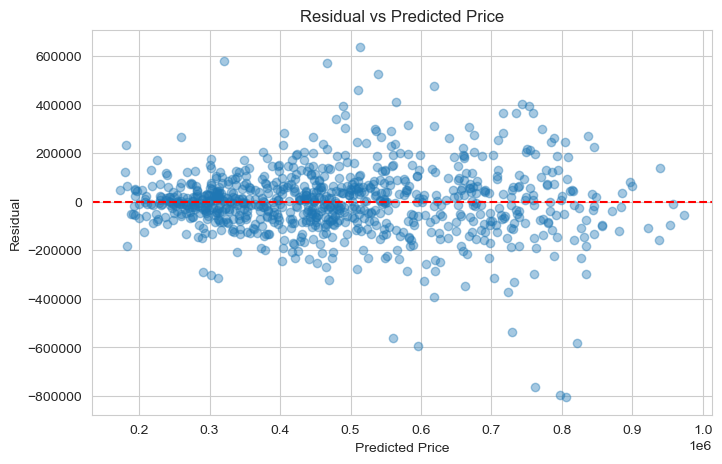

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual vs Predicted Price")
plt.show()

7. FEATURE IMPORTANCE

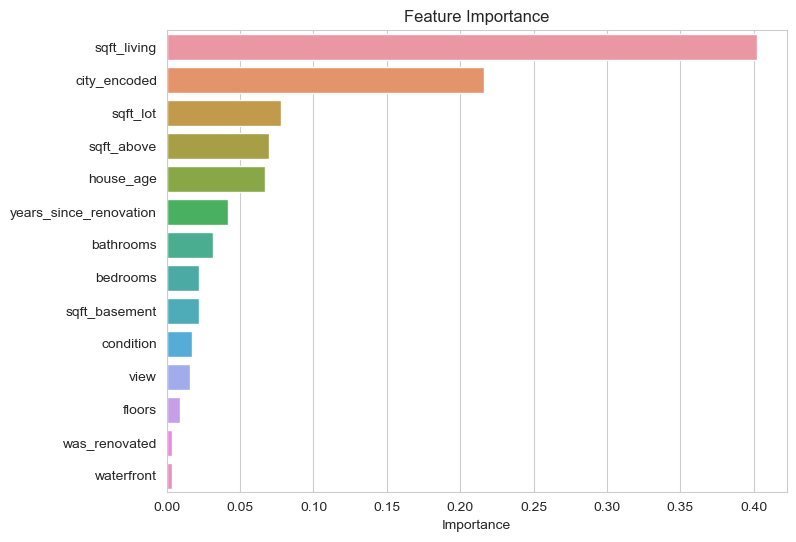

sqft_living               0.402382
city_encoded              0.216377
sqft_lot                  0.077549
sqft_above                0.069415
house_age                 0.066648
years_since_renovation    0.041828
bathrooms                 0.031433
bedrooms                  0.022236
sqft_basement             0.022101
condition                 0.017437
view                      0.015952
floors                    0.009073
was_renovated             0.003849
waterfront                0.003720
dtype: float64

In [10]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.xlabel('Importance')
plt.show()

importances

8. EXAMPLE OF PREDICTED NEW HOUSE

In [11]:
contoh_rumah = X_test.iloc[[0]]
prediksi_harga = model.predict(contoh_rumah)[0]
harga_aktual = y_test.iloc[0]

print('Data rumah:')
print(contoh_rumah)
print(f'Harga aktual   : {harga_aktual:,.2f}')
print(f'Harga prediksi : {prediksi_harga:,.2f}')


Data rumah:
   bedrooms  bathrooms  ...  years_since_renovation  city_encoded
0       4.0        2.5  ...                       7      0.063696

[1 rows x 14 columns]
Harga aktual   : 550,000.00
Harga prediksi : 501,325.98
